In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('garments_worker_productivity.csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [4]:
synonyms = {
    'finishing ': 'finishing',
}

df['department'] = df['department'].replace(synonyms)

In [5]:
# Infromasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [6]:
# Deskripsi statistik
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [ ]:
# Mencari missing values
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [8]:
df_clean = df.copy()

cols = ['wip']
imputer = SimpleImputer(strategy='median')
df_clean[cols] = imputer.fit_transform(df_clean[cols])

df_clean.isnull().sum()

date                     0
quarter                  0
department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64

In [9]:
df_clean.head(10)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [10]:
# Encode categorical features
categorical_cols = ['quarter', 'department', 'day']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

In [11]:
df_clean.head(10)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,quarter_encoded,department_encoded,day_encoded
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,0,1,3
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,0.886500,0,0,3
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0,1,3
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,0,1,3
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,0,1,3
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125,0,1,3
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,0.755167,0,0,3
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683,0,1,3
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098,0,1,3
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428,0,1,3


In [12]:
features = ['targeted_productivity', 'team', 'smv', 'wip', 'over_time', 'incentive', 
           'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
           'quarter_encoded', 'department_encoded', 'day_encoded']


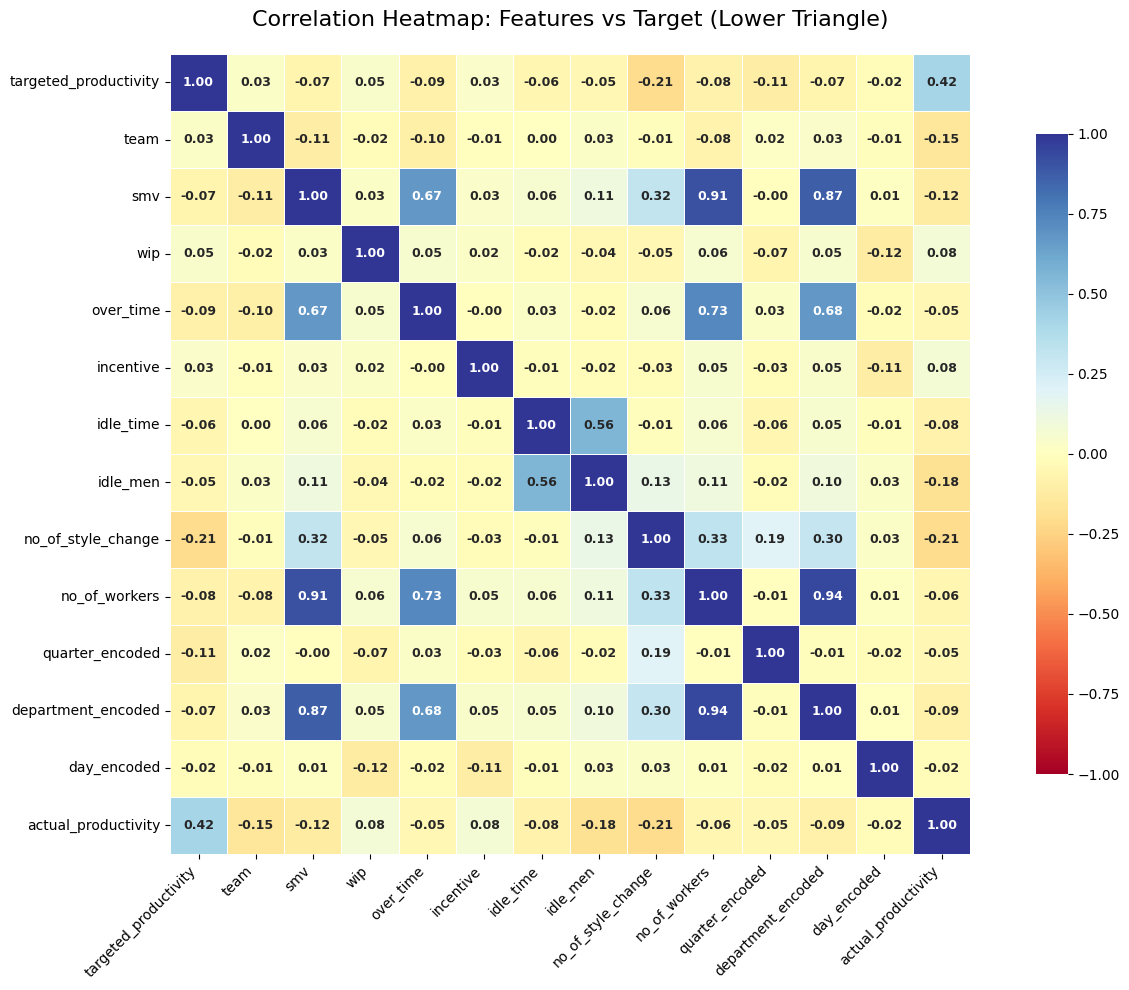

In [13]:
# Heatmap Visualization
corr_df = df_clean[features + ['actual_productivity']]
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt='.2f',
            cmap='RdYlBu',
            vmin=-1, vmax=1,
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9, 'weight': 'bold'},  # Teks bold
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Correlation Heatmap: Features vs Target (Lower Triangle)", 
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()


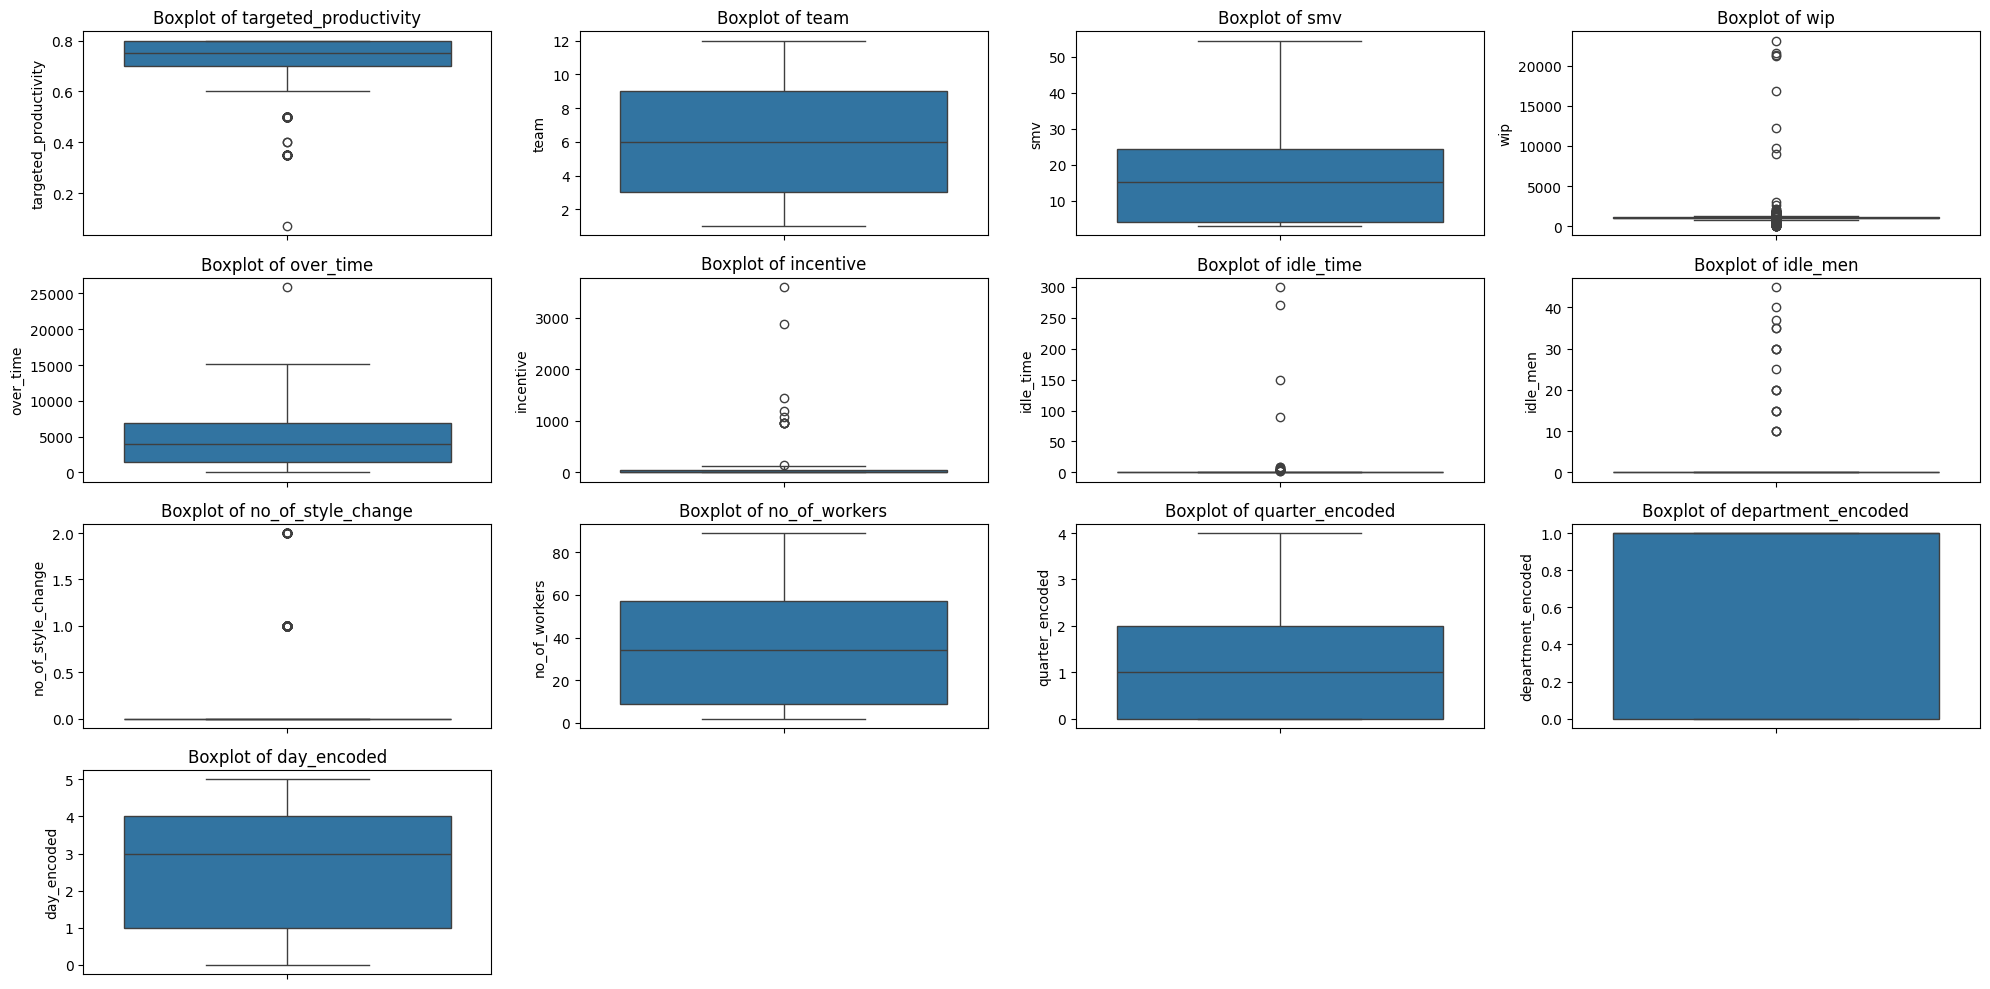

In [14]:
plt.figure(figsize=(20, 10))

# Membuat boxplot untuk setiap feature
for i, feature in enumerate(features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[feature])
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

In [15]:
for i, feature in enumerate(features, 1):
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)]
    print(f"Jumlah outlier pada {feature}: {outliers.shape[0]}")
  

Jumlah outlier pada targeted_productivity: 79
Jumlah outlier pada team: 0
Jumlah outlier pada smv: 0
Jumlah outlier pada wip: 358
Jumlah outlier pada over_time: 1
Jumlah outlier pada incentive: 11
Jumlah outlier pada idle_time: 18
Jumlah outlier pada idle_men: 18
Jumlah outlier pada no_of_style_change: 147
Jumlah outlier pada no_of_workers: 0
Jumlah outlier pada quarter_encoded: 0
Jumlah outlier pada department_encoded: 0
Jumlah outlier pada day_encoded: 0


In [16]:
import pandas as pd

# --- Masukkan nama fitur numerik yang ingin dicek ---
numeric_features = [
    'wip', 'incentive',
]

# Dictionary untuk menyimpan outlier per fitur
outlier_data = {}

for feature in numeric_features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ambil data yang outlier
    outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)]
    
    # Simpan ke dictionary
    outlier_data[feature] = {
        "jumlah_outlier": len(outliers),
        "data_outlier": outliers
    }

# --- Tampilkan jumlah outlier ---
outlier_summary = pd.DataFrame({
    "feature": list(outlier_data.keys()),
    "jumlah_outlier": [outlier_data[f]["jumlah_outlier"] for f in outlier_data]
})

print("Jumlah Outlier per Fitur:")
display(outlier_summary)

# --- Contoh: melihat data outlier khusus fitur wip ---
print("\nData Outlier untuk fitur 'wip':")
display(outlier_data['incentive']["data_outlier"])


Jumlah Outlier per Fitur:


,feature,jumlah_outlier
0,wip,358
1,incentive,11



Data Outlier untuk fitur 'wip':


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,quarter_encoded,department_encoded,day_encoded
730,2/12/2015,Quarter2,sweing,Thursday,1,0.80,22.52,1397.0,0,138,0.0,0,0,57.0,1.100484,1,1,3
1128,3/9/2015,Quarter2,finishing,Monday,11,0.80,2.90,1039.0,0,960,0.0,0,0,8.0,0.960625,1,0,0
1129,3/9/2015,Quarter2,finishing,Monday,12,0.80,4.60,1039.0,0,1080,0.0,0,0,9.0,0.902963,1,0,0
1130,3/9/2015,Quarter2,finishing,Monday,5,0.60,3.94,1039.0,0,2880,0.0,0,0,12.0,0.864343,1,0,0
1133,3/9/2015,Quarter2,finishing,Monday,9,0.75,2.90,1039.0,0,3600,0.0,0,0,15.0,0.841000,1,0,0
1137,3/9/2015,Quarter2,finishing,Monday,3,0.80,4.60,1039.0,0,1440,0.0,0,0,12.0,0.795417,1,0,0
1138,3/9/2015,Quarter2,finishing,Monday,4,0.75,3.94,1039.0,0,960,0.0,0,0,8.0,0.795388,1,0,0
1139,3/9/2015,Quarter2,finishing,Monday,1,0.75,3.94,1039.0,0,960,0.0,0,0,8.0,0.794567,1,0,0
1143,3/9/2015,Quarter2,finishing,Monday,2,0.70,3.90,1039.0,0,1200,0.0,0,0,10.0,0.682500,1,0,0
1148,3/9/2015,Quarter2,finishing,Monday,10,0.70,2.90,1039.0,0,960,0.0,0,0,8.0,0.477292,1,0,0


In [17]:
# feature_outliers = ['targeted_productivity', 'wip', 'incentive', 'idle_time', 'idle_men', 'over_time']
feature_outliers = ['wip', 'incentive', 
                    # 'over_time', 'idle_time', 'idle_men',
                    ]

print(df_clean[feature_outliers].describe())

# df_clean['wip'] = np.log1p(df_clean['wip'])

Q1 = df_clean[feature_outliers].quantile(0.25)
Q3 = df_clean[feature_outliers].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean[feature_outliers] = np.where(df_clean[feature_outliers] < lower_bound, lower_bound, df_clean[feature_outliers])
df_clean[feature_outliers] = np.where(df_clean[feature_outliers] > upper_bound, upper_bound, df_clean[feature_outliers])

print(df_clean[feature_outliers].describe())
    
for i, feature in enumerate(feature_outliers, 1):
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)]
    print(f"Jumlah outlier pada {feature}: {outliers.shape[0]}")

                wip    incentive
count   1197.000000  1197.000000
mean    1126.437761    38.210526
std     1397.653191   160.182643
min        7.000000     0.000000
25%      970.000000     0.000000
50%     1039.000000     0.000000
75%     1083.000000    50.000000
max    23122.000000  3600.000000
               wip    incentive
count  1197.000000  1197.000000
mean   1031.530493    26.712615
std     139.264235    31.563351
min     800.500000     0.000000
25%     970.000000     0.000000
50%    1039.000000     0.000000
75%    1083.000000    50.000000
max    1252.500000   125.000000
Jumlah outlier pada wip: 0
Jumlah outlier pada incentive: 0


In [18]:
df_clean.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,quarter_encoded,department_encoded,day_encoded
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1031.530493,4567.460317,26.712615,0.730159,0.369256,0.150376,34.609858,0.735091,1.399332,0.577277,2.534670
std,3.463963,0.097891,10.943219,139.264235,3348.823563,31.563351,12.709757,3.268987,0.427848,22.197687,0.174488,1.215535,0.494199,1.714538
min,1.000000,0.070000,2.900000,800.500000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705,0.000000,0.000000,0.000000
25%,3.000000,0.700000,3.940000,970.000000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307,0.000000,0.000000,1.000000
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333,1.000000,1.000000,3.000000
75%,9.000000,0.800000,24.260000,1083.000000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253,2.000000,1.000000,4.000000
max,12.000000,0.800000,54.560000,1252.500000,25920.000000,125.000000,300.000000,45.000000,2.000000,89.000000,1.120437,4.000000,1.000000,5.000000


<Axes: xlabel='actual_productivity', ylabel='Count'>

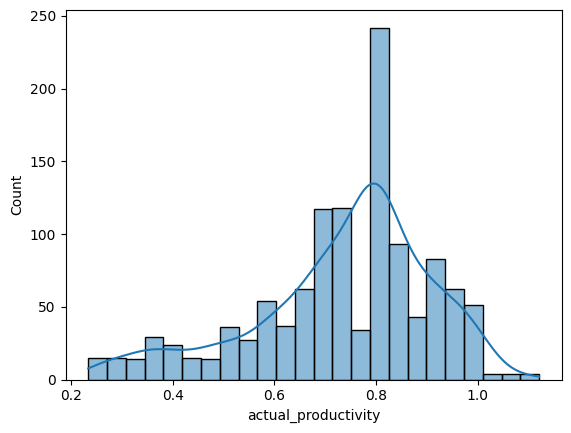

In [19]:
sns.histplot(df_clean['actual_productivity'], kde=True)


In [20]:
# Fitur yang digunakan
features_used = ['targeted_productivity', 'no_of_style_change', 'idle_time', 'idle_men',
                 'over_time', 'smv', 'no_of_workers', 'department_encoded',
                #  'incentive', 'wip'
                ]


# Train, Test, Split, dan Scaling
X = df_clean[features_used]
y = df_clean['actual_productivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Neural Network Model
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',

    alpha=0.005,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    batch_size=16,

    max_iter=1500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,

    random_state=42,
)

nn_model.fit(X_train_scaled, y_train)


MLPRegressor(alpha=0.005, batch_size=16, early_stopping=True,
             hidden_layer_sizes=(64, 32, 16), learning_rate='adaptive',
             max_iter=1500, n_iter_no_change=20, random_state=42,
             validation_fraction=0.15)

In [21]:
print(f"Training iterations: {nn_model.n_iter_}")
print(f"Final loss: {nn_model.loss_:.4f}")

Training iterations: 97
Final loss: 0.0114


In [22]:
# Evaluasi model
y_pred_train = nn_model.predict(X_train_scaled)
y_pred_test = nn_model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Training MSE : {train_mse:.4f}; Testing MSE : {test_mse:.4f}")
print(f"Training RMSE: {train_rmse:.4f}; Testing RMSE: {test_rmse:.4f}")
print(f"Training MAE : {train_mae:.4f}; Testing MAE : {test_mae:.4f}")
print(f"Training R2  : {train_r2:.4f}; Testing R2  : {test_r2:.4f}")


Training MSE : 0.0187; Testing MSE : 0.0167
Training RMSE: 0.1368; Testing RMSE: 0.1294
Training MAE : 0.0971; Testing MAE : 0.0933
Training R2  : 0.4036; Testing R2  : 0.3695


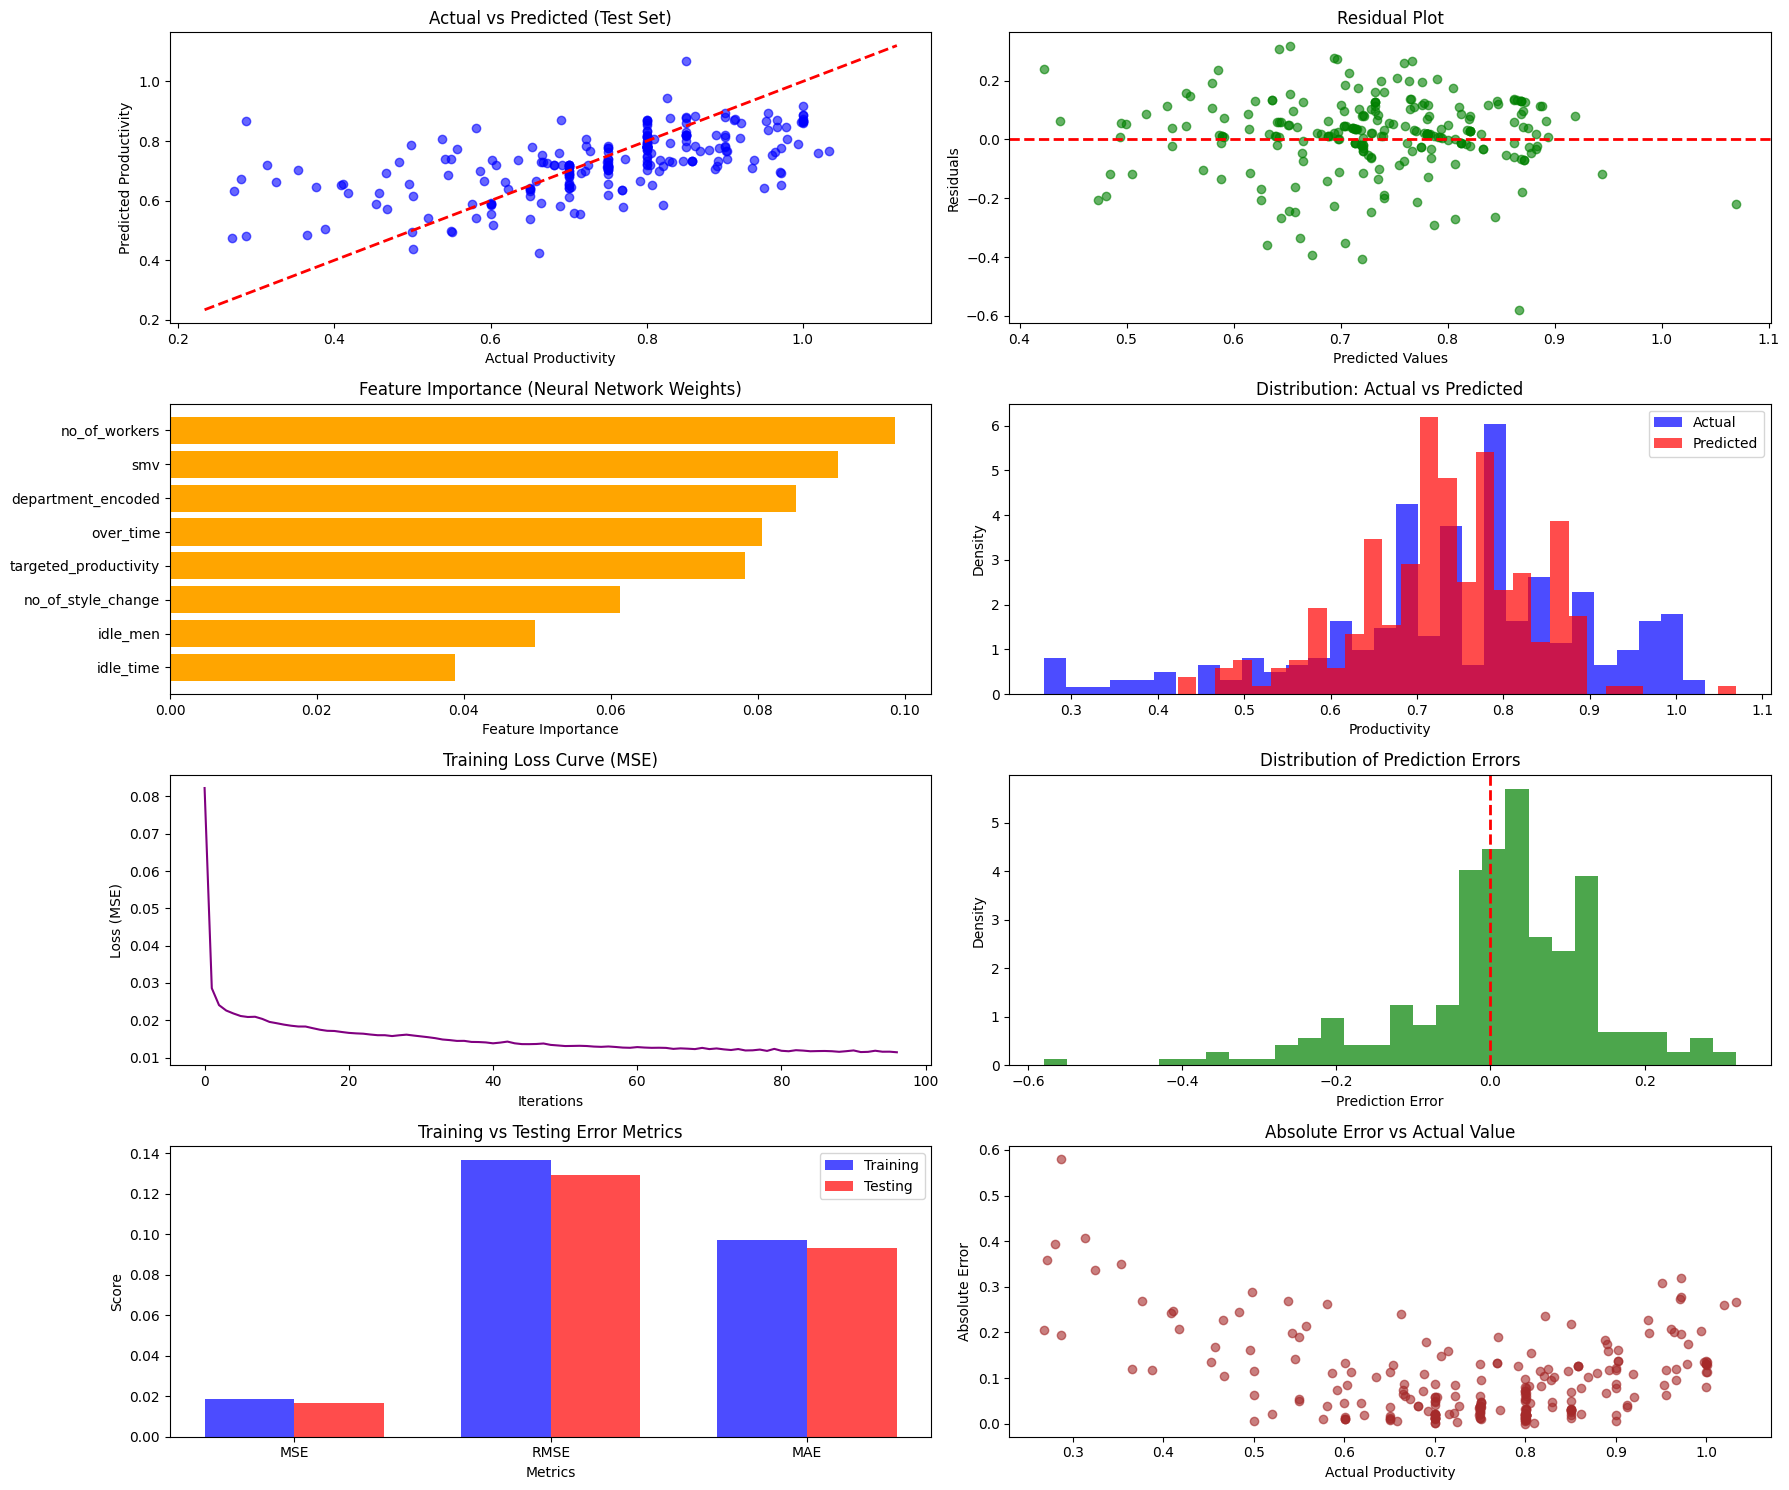

In [23]:
plt.figure(figsize=(18, 15))

# Actual vs Predicted
plt.subplot(4, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Productivity')
plt.ylabel('Predicted Productivity')
plt.title('Actual vs Predicted (Test Set)')

# Residual plot
plt.subplot(4, 2, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Feature importance (berdasarkan weights)
plt.subplot(4, 2, 3)
if hasattr(nn_model, 'coefs_'):
    feature_importance = np.abs(nn_model.coefs_[0]).mean(axis=1)
    feature_names = features_used
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=True)
    
    plt.barh(importance_df['feature'], importance_df['importance'], color='orange')
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance (Neural Network Weights)')

# Distribution of predictions vs actual
plt.subplot(4, 2, 4)
plt.hist(y_test, bins=30, alpha=0.7, label='Actual', color='blue', density=True)
plt.hist(y_pred_test, bins=30, alpha=0.7, label='Predicted', color='red', density=True)
plt.xlabel('Productivity')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution: Actual vs Predicted')

# Training history (jika tersedia)
plt.subplot(4, 2, 5)
if hasattr(nn_model, 'loss_curve_'):
    plt.plot(nn_model.loss_curve_, color='purple')
    plt.xlabel('Iterations')
    plt.ylabel('Loss (MSE)')
    plt.title('Training Loss Curve (MSE)')

# Error distribution
plt.subplot(4, 2, 6)
plt.hist(residuals, bins=30, alpha=0.7, color='green', density=True)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.title('Distribution of Prediction Errors')

# Perbandingan metrik error
plt.subplot(4, 2, 7)
metrics = ['MSE', 'RMSE', 'MAE']
train_scores = [train_mse, train_rmse, train_mae]
test_scores = [test_mse, test_rmse, test_mae]

x_pos = np.arange(len(metrics))
width = 0.35

plt.bar(x_pos - width/2, train_scores, width, label='Training', color='blue', alpha=0.7)
plt.bar(x_pos + width/2, test_scores, width, label='Testing', color='red', alpha=0.7)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Training vs Testing Error Metrics')
plt.xticks(x_pos, metrics)
plt.legend()

# Scatter plot error vs actual
plt.subplot(4, 2, 8)
absolute_errors = np.abs(residuals)
plt.scatter(y_test, absolute_errors, alpha=0.6, color='brown')
plt.xlabel('Actual Productivity')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs Actual Value')

plt.tight_layout()
plt.show()

In [24]:
# Hitung berbagai jenis error
max_error = np.max(np.abs(residuals))
mean_absolute_percentage_error = np.mean(np.abs(residuals / y_test)) * 100

# Analisis error detail
print(f"Maximum Absolute Error: {max_error:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error:.2f}%")
print(f"Standard Deviation of Errors: {np.std(residuals):.6f}")

# Error distribution statistics
error_stats = pd.DataFrame(residuals).describe()
print(f"\nError Distribution Statistics:")
print(error_stats)

Maximum Absolute Error: 0.579313
Mean Absolute Percentage Error (MAPE): 15.40%
Standard Deviation of Errors: 0.128613

Error Distribution Statistics:
       actual_productivity
count           240.000000
mean              0.014175
std               0.128882
min              -0.579313
25%              -0.025297
50%               0.021152
75%               0.089198
max               0.318905


In [25]:
#  Analisis per departemen dan quarter

# Prediksi untuk berbagai kategori
df_clean['predicted_productivity'] = nn_model.predict(scaler.transform(X))
df_clean['prediction_error'] = df_clean['actual_productivity'] - df_clean['predicted_productivity']
df_clean['absolute_error'] = np.abs(df_clean['prediction_error'])

#  Analisis per departemen
dept_analysis = df_clean.groupby('department').agg({
    'actual_productivity': ['mean', 'std'],
    'predicted_productivity': ['mean', 'std'],
    'absolute_error': ['mean', 'std']
}).round(6)

print(f"\nAnalisis Error per Department:")
dept_analysis


Analisis Error per Department:


actual_productivity           predicted_productivity            \
                          mean       std                   mean       std   
department                                                                  
finishing             0.752951  0.197021               0.730295  0.068065   
sweing                0.722013  0.154784               0.712599  0.121504   

           absolute_error            
                     mean       std  
department                           
finishing        0.147826  0.105001  
sweing           0.058685  0.064949

In [26]:
#  Analisis per quarter
quarter_analysis = df_clean.groupby('quarter').agg({
    'actual_productivity': ['mean', 'std'],
    'predicted_productivity': ['mean', 'std'],
    'absolute_error': ['mean', 'std']
}).round(6)
print("\nAnalisis Error per Quarter:")
quarter_analysis


Analisis Error per Quarter:


actual_productivity           predicted_productivity            \
                        mean       std                   mean       std   
quarter                                                                   
Quarter1            0.751560  0.161318               0.736738  0.100327   
Quarter2            0.743710  0.171114               0.728142  0.103424   
Quarter3            0.704759  0.175614               0.699951  0.107518   
Quarter4            0.709067  0.185983               0.701960  0.095203   
Quarter5            0.826177  0.183851               0.720593  0.106595   

         absolute_error            
                   mean       std  
quarter                            
Quarter1       0.088094  0.087616  
Quarter2       0.094774  0.092157  
Quarter3       0.094114  0.103006  
Quarter4       0.102810  0.097852  
Quarter5       0.150617  0.103207

In [27]:
department = df['department'].value_counts().sort_index()
department_encoded = df_clean[['department', 'department_encoded']].drop_duplicates().sort_values('department_encoded')
print(department_encoded)

  department  department_encoded
1  finishing                   0
0     sweing                   1


In [28]:
# Contoh data baru untuk prediksi
sample_data = {
    'targeted_productivity': [0.8],
    'no_of_style_change': [0],  
    'idle_time': [0],
    'idle_men': [0],
    'over_time': [5000],
    'smv': [20.0],
    'no_of_workers': [50],
    'department_encoded': [0],
    # 'incentive': [50],
    # 'wip': [1039],
    # 'quarter_encoded': [1],  # Quarter2
    # 'day_encoded': [3],  # Thursday
}

sample_df = pd.DataFrame(sample_data)
sample_scaled = scaler.transform(sample_df)

prediction = nn_model.predict(sample_scaled)[0]
print(f"Prediksi Produktivitas untuk Data Contoh: {prediction:.6f}")

Prediksi Produktivitas untuk Data Contoh: 1.078282
